# Unsupervised Learning and Clustering for Dog Growth Profiles

This notebook connects the third course topic, **Unsupervised Learning and Clustering**, to the Cane Corso Growth Intelligence project.

The practical idea is not only to run clustering algorithms. The goal is to show how a real owner-facing growth-monitoring problem can be translated into a mathematical structure-discovery problem.

In earlier notebooks:

- regression estimated a numerical value, such as expected weight;
- classification predicted a known label, such as `normal_growth` or `needs_attention`.

In this notebook:

- clustering explores hidden groups when no target label is available.

Project question:

```text
Which growth records look naturally similar before a human-defined label is assigned?
```

Possible product use:

```text
An owner records age, weight and body measurements.
The system groups the record with similar growth profiles.
The result can support awareness, comparison and review.
```

Responsible interpretation: clusters are **exploratory mathematical groups**, not veterinary diagnoses, not breed certification, and not official health categories.


## Mathematical Formulation

A dog growth record is represented as a numeric feature vector:

```text
x_i = [age_months, weight_kg, average_adult_breed_weight_kg,
       weight_to_adult_ratio, age_weight_ratio, adult_weight_group]
```

All records form a feature matrix:

```text
X = [x_1, x_2, ..., x_n]^T
```

There is no target variable:

```text
y = not used
```

That is the key difference from supervised learning. The model does not learn from known answers. It searches for structure in the geometry of the data.

Because clustering uses distances, each feature must be scaled. Otherwise, a feature measured in large numeric units can dominate the distance calculation.

The main distance idea is Euclidean distance:

```text
d(x_i, x_j) = sqrt(sum((x_i,k - x_j,k)^2))
```

### K-Means objective

K-Means chooses `k` centroids:

```text
mu_1, mu_2, ..., mu_k
```

Each point is assigned to the nearest centroid:

```text
c(i) = argmin_j ||x_i - mu_j||^2
```

The algorithm tries to minimize within-cluster squared distance:

```text
J = sum_i ||x_i - mu_c(i)||^2
```

### Hierarchical clustering objective

Agglomerative hierarchical clustering starts with every point as its own group and repeatedly merges the closest groups. With Ward linkage, the merge is chosen to keep within-cluster variance as low as possible.

### DBSCAN density idea

DBSCAN uses density instead of centroids:

```text
eps = neighborhood radius
min_samples = minimum points required in that neighborhood
```

A point can be a core point, border point, or noise point. In this project, a DBSCAN noise point means only:

```text
this record does not fit a dense mathematical neighborhood in the selected feature space
```

It does not mean a medical problem.


## Course Coverage in This Notebook

This notebook covers:

- Unsupervised Learning problem statement, intuition and challenges;
- K-Means Clustering motivation, example and `k-means++` initialization;
- Hierarchical Clustering motivation and example;
- comparison between K-Means and Hierarchical Clustering;
- DBSCAN for density-based clustering and outlier/noise detection.

Step 09.2 aligns this notebook more closely with the exact lecture structure by adding:

- k-Nearest Neighbors as a distance-based lazy-learning section;
- synthetic blobs, moons and circles examples;
- K-Means random initialization vs K-Means++ comparison context;
- silhouette samples, not only average silhouette score;
- hierarchical dendrogram visualization;
- clustering vs classification comparison using Adjusted Rand Index.


## Practical Application Logic

For this project, clustering is useful because not every useful growth pattern has a ready-made label.

A practical owner-facing system could use the clustering result like this:

```text
Input: one growth record or one growth stage
Math: place the record in feature space
Model: compare it with nearby records or cluster centers
Output: show a careful growth-profile hint
```

Example interpretation:

```text
This record resembles a heavier / faster growth-profile group in this dataset.
```

Safe interpretation:

```text
This is a data similarity signal. It can help decide what to review, but it cannot diagnose health, prove breed quality, or replace a veterinarian.
```

This is the application bridge that makes the lecture useful in the Cane Corso Growth Intelligence idea.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dog_growth_public_sample.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)


## 1. Load the Processed Real Public Growth Sample

The notebook uses the processed public dog growth sample already included in the project.

The original raw dataset archive is not required for this notebook.


In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(10000, 12)


,breed_id,pet_id,gender,visit_age_years,visit_age_months,weight_kg,bcs_recorded,bcs_predicted,preventive_care_visit,healthy_pet_diagnosis,average_adult_breed_weight_kg,source_type
0,11,952168,F,0.298,3.58,16.919,NaN,NaN,Y,Y,35.91,real_public_processed_sample
1,11,952169,M,0.169,2.03,7.938,Thin,NaN,N,N,35.91,real_public_processed_sample
2,11,952169,M,0.355,4.26,12.610,NaN,NaN,Y,N,35.91,real_public_processed_sample
3,11,952170,FS,0.355,4.26,16.964,NaN,NaN,N,N,35.91,real_public_processed_sample
4,11,952170,FS,0.421,5.05,21.364,NaN,NaN,Y,Y,35.91,real_public_processed_sample


## 2. Feature Preparation for Clustering

Clustering is distance-based, so feature preparation is especially important.

I create a small set of numeric features that describe each growth record:

- age in months;
- current weight;
- average adult breed weight;
- ratio between current weight and expected adult breed weight;
- age-to-weight relationship;
- rough adult breed weight group.

The sample is limited to keep the notebook fast and easy to run in a student environment.


In [3]:
work = df.dropna(
    subset=["visit_age_months", "weight_kg", "average_adult_breed_weight_kg"]
).copy()

work = work[
    (work["visit_age_months"] >= 0)
    & (work["visit_age_months"] <= 84)
    & (work["weight_kg"] > 0)
    & (work["average_adult_breed_weight_kg"] > 0)
].copy()

work = work.sample(n=min(500, len(work)), random_state=RANDOM_STATE).reset_index(drop=True)

work["weight_to_adult_ratio"] = work["weight_kg"] / work["average_adult_breed_weight_kg"]
work["age_weight_ratio"] = work["weight_kg"] / (work["visit_age_months"] + 1)
work["adult_weight_group"] = pd.cut(
    work["average_adult_breed_weight_kg"],
    bins=[0, 10, 25, 45, 200],
    labels=[0, 1, 2, 3],
).astype(int)

features = [
    "visit_age_months",
    "weight_kg",
    "average_adult_breed_weight_kg",
    "weight_to_adult_ratio",
    "age_weight_ratio",
    "adult_weight_group",
]

X = work[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Clustering sample shape:", X.shape)
X.head()


Clustering sample shape: (500, 6)


,visit_age_months,weight_kg,average_adult_breed_weight_kg,weight_to_adult_ratio,age_weight_ratio,adult_weight_group
0,2.09,7.530,35.91,0.209691,2.436893,2
1,2.03,6.577,35.91,0.183152,2.170627,2
2,34.27,45.359,35.91,1.263130,1.286050,2
3,4.36,18.234,35.91,0.507769,3.401866,2
4,11.20,40.914,35.91,1.139348,3.353607,2


## 3. k-Nearest Neighbors: Distance-Based Lazy Learning

The lecture includes **k-Nearest Neighbors (kNN)** before clustering. kNN is not an unsupervised clustering algorithm, because it normally uses labels, but it is important here because it uses the same geometric idea as clustering: **distance between points in feature space**.

In the growth-monitoring project, kNN can answer a simple educational question:

```text
Given a new growth record, which previously seen records are closest to it?
```

Mathematical view:

```text
x_i = feature vector for one growth record
x_new = new growth record
```

The distance can be expressed with Minkowski distance:

```text
d(x_i, x_new) = (sum_j |x_ij - x_new_j|^p)^(1/p)
```

When `p = 2`, this becomes Euclidean distance. kNN then finds the `k` closest records and, for classification, uses a majority vote.

In this notebook we create an educational target from `weight_to_adult_ratio` bands only to demonstrate the lecture concept. This is not a medical label.


In [4]:
# Educational kNN target: low / middle / high weight-to-adult-ratio band.
# This is created only to demonstrate the lecture's kNN idea.
work["growth_ratio_band"] = pd.qcut(
    work["weight_to_adult_ratio"].rank(method="first"),
    q=3,
    labels=["lower_ratio", "middle_ratio", "higher_ratio"],
)

X_knn = X_scaled
y_knn = work["growth_ratio_band"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X_knn,
    y_knn,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_knn,
)

knn_results = []
for k in [1, 3, 5, 9, 15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2)
    knn.fit(X_train, y_train)
    predictions = knn.predict(X_test)
    knn_results.append({"k": k, "accuracy": accuracy_score(y_test, predictions)})

pd.DataFrame(knn_results)


,k,accuracy
0,1,0.952
1,3,0.968
2,5,0.960
3,9,0.952
4,15,0.928


### kNN Interpretation

A smaller `k` can react strongly to local details and noise. A larger `k` is smoother, but it can hide small local differences. This is the bias / variance idea from the lecture.

For the Cane Corso project, kNN is useful mainly as a **similar-record lookup idea**:

```text
show me the most similar historical growth records
```

It should not be treated as a final veterinary decision.


## 5. Unsupervised Learning: Intuition and Challenges

In supervised learning, the model has a known answer during training:

```text
X -> y
```

In unsupervised learning, there is no known target label:

```text
X -> hidden structure
```

Main challenges:

- clusters may not have a real biological meaning;
- different scaling can change the result;
- different algorithms can produce different groups;
- the number of clusters is not always obvious;
- outliers can strongly affect distance-based methods.

For this project, the safe interpretation is:

```text
clustering suggests growth-pattern groups for exploration only
```


## 4. Synthetic Clustering Examples: Blobs, Moons and Circles

The lecture demonstrates clustering on generated datasets such as blobs, moons and circles. We include this section because it shows an important lesson:

```text
The best clustering algorithm depends on the shape of the data.
```

K-Means often works well for compact, spherical clusters. DBSCAN can work better for density-shaped or non-spherical structures, but it depends strongly on `eps` and `min_samples`.


In [5]:
def cluster_quality_summary(name, attributes, true_labels, n_clusters, dbscan_eps):
    attributes_scaled = StandardScaler().fit_transform(attributes)

    kmeans_random = KMeans(n_clusters=n_clusters, init="random", n_init=10, random_state=RANDOM_STATE)
    kmeans_plus = KMeans(n_clusters=n_clusters, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    dbscan_model = DBSCAN(eps=dbscan_eps, min_samples=5)

    random_labels = kmeans_random.fit_predict(attributes_scaled)
    plus_labels = kmeans_plus.fit_predict(attributes_scaled)
    dbscan_labels = dbscan_model.fit_predict(attributes_scaled)

    rows = []
    for method_name, labels, inertia in [
        ("K-Means random", random_labels, kmeans_random.inertia_),
        ("K-Means++", plus_labels, kmeans_plus.inertia_),
        ("DBSCAN", dbscan_labels, np.nan),
    ]:
        valid_cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
        if valid_cluster_count >= 2:
            sil = silhouette_score(attributes_scaled, labels)
        else:
            sil = np.nan

        rows.append(
            {
                "dataset": name,
                "method": method_name,
                "clusters_found": valid_cluster_count,
                "noise_points": int(np.sum(labels == -1)),
                "ARI_vs_true_generation": adjusted_rand_score(true_labels, labels),
                "silhouette": sil,
                "inertia": inertia,
            }
        )

    return pd.DataFrame(rows), attributes_scaled, plus_labels, dbscan_labels

synthetic_datasets = []
blobs_X, blobs_y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.6,
    random_state=RANDOM_STATE,
)
synthetic_datasets.append(("blobs", blobs_X, blobs_y, 3, 0.45))

moons_X, moons_y = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
synthetic_datasets.append(("moons", moons_X, moons_y, 2, 0.25))

circles_X, circles_y = make_circles(
    n_samples=300,
    factor=0.45,
    noise=0.05,
    random_state=RANDOM_STATE,
)
synthetic_datasets.append(("circles", circles_X, circles_y, 2, 0.20))

synthetic_results = []
plot_payload = []
for item in synthetic_datasets:
    result_table, scaled_attributes, plus_labels, dbscan_labels = cluster_quality_summary(*item)
    synthetic_results.append(result_table)
    plot_payload.append((item[0], scaled_attributes, item[2], plus_labels, dbscan_labels))

synthetic_comparison_df = pd.concat(synthetic_results, ignore_index=True)
synthetic_comparison_df.round(3)


,dataset,method,clusters_found,noise_points,ARI_vs_true_generation,silhouette,inertia
0,blobs,K-Means random,3,0,1.000,0.758,43.937
1,blobs,K-Means++,3,0,1.000,0.758,43.937
2,blobs,DBSCAN,3,1,0.995,0.667,NaN
3,moons,K-Means random,2,0,0.479,0.494,250.926
4,moons,K-Means++,2,0,0.479,0.494,250.926
5,moons,DBSCAN,2,2,0.987,0.192,NaN
6,circles,K-Means random,2,0,-0.003,0.341,384.582
7,circles,K-Means++,2,0,-0.003,0.341,384.333
8,circles,DBSCAN,19,30,0.528,0.112,NaN


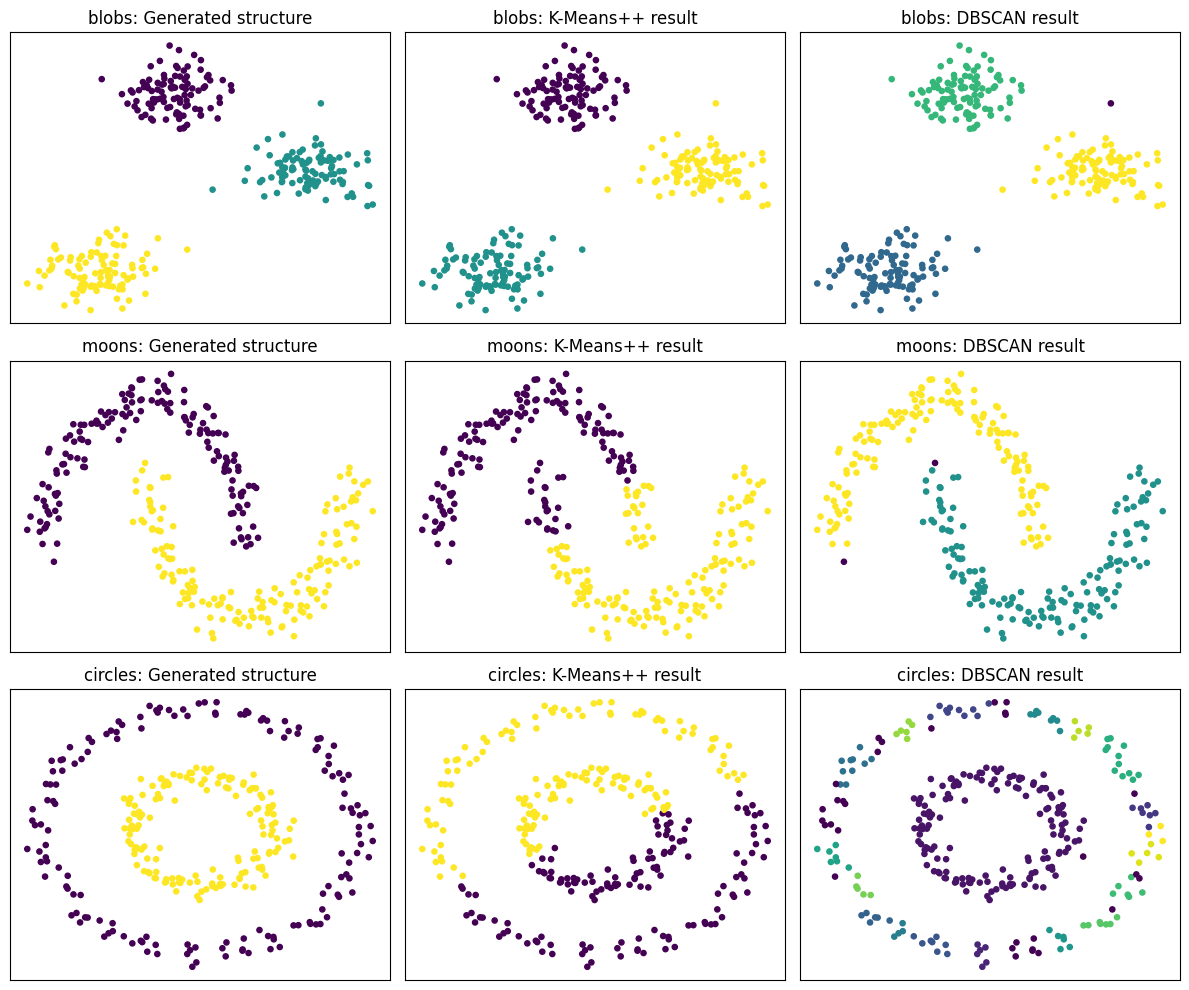

In [6]:
fig, axes = plt.subplots(len(plot_payload), 3, figsize=(12, 10))

for row_index, (name, attributes_scaled, true_labels, kmeans_labels, dbscan_labels) in enumerate(plot_payload):
    for col_index, (title, labels) in enumerate(
        [
            ("Generated structure", true_labels),
            ("K-Means++ result", kmeans_labels),
            ("DBSCAN result", dbscan_labels),
        ]
    ):
        ax = axes[row_index, col_index]
        ax.scatter(attributes_scaled[:, 0], attributes_scaled[:, 1], c=labels, s=14)
        ax.set_title(f"{name}: {title}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "synthetic_clustering_comparison.png", dpi=160)
plt.show()


### Synthetic Example Interpretation

This section connects directly to the lecture examples.

- **Blobs** are close to the ideal K-Means case because they are compact and approximately spherical.
- **Moons** and **circles** show why K-Means can struggle with non-spherical shapes.
- **DBSCAN** can detect density-shaped clusters, but only when its parameters fit the scale of the data.

For the project, this matters because real growth records may not form perfect spherical groups. Domain knowledge and evaluation metrics are necessary.


## 6. K-Means Clustering with k-means++

K-Means tries to place `k` centroids and assign each point to the nearest centroid.

The objective is to reduce within-cluster squared distance:

```text
minimize sum(distance(point, assigned_centroid)^2)
```

The `k-means++` initialization helps choose better starting centroids than random initialization. This can make the result more stable.


In [7]:
kmeans_scores = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(X_scaled)
    kmeans_scores.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        }
    )

kmeans_scores_df = pd.DataFrame(kmeans_scores)
kmeans_scores_df


,k,inertia,silhouette,davies_bouldin
0,2,1024.385078,0.457879,0.889871
1,3,635.354041,0.443737,0.808957
2,4,492.406391,0.430964,0.842749
3,5,415.306042,0.376136,0.947411
4,6,344.957458,0.388385,0.848310


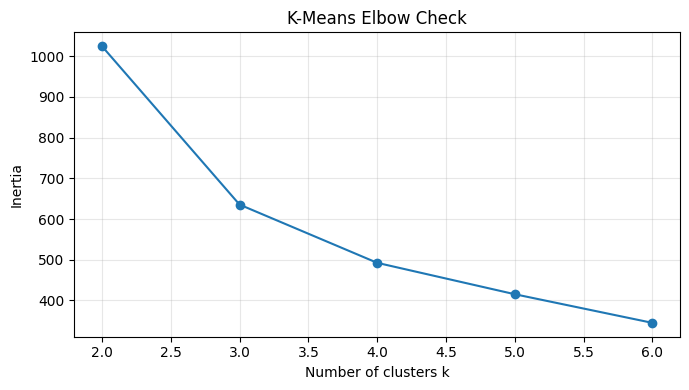

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(kmeans_scores_df["k"], kmeans_scores_df["inertia"], marker="o")
plt.title("K-Means Elbow Check")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_elbow_check.png", dpi=160)
plt.show()


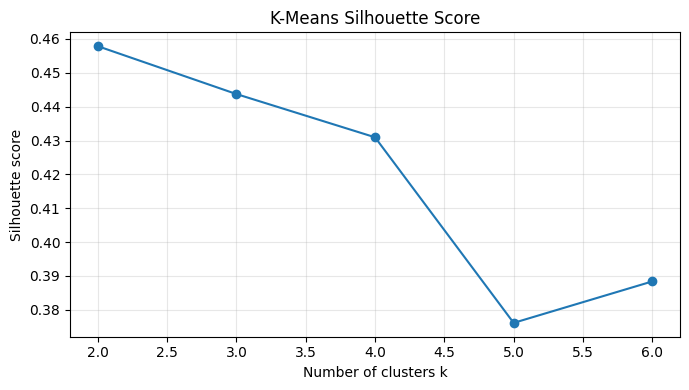

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(kmeans_scores_df["k"], kmeans_scores_df["silhouette"], marker="o")
plt.title("K-Means Silhouette Score")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_silhouette_score.png", dpi=160)
plt.show()


### K-Means Example with 3 Clusters

I use 3 clusters as an easy educational example. The purpose is not to claim that exactly three true biological growth groups exist. The purpose is to show how K-Means groups records by similarity.


In [10]:
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=RANDOM_STATE)
work["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = work.groupby("kmeans_cluster")[features].mean().round(2)
cluster_summary["records"] = work["kmeans_cluster"].value_counts().sort_index().values

ratio_low = cluster_summary["weight_to_adult_ratio"].quantile(0.33)
ratio_high = cluster_summary["weight_to_adult_ratio"].quantile(0.66)
age_median = cluster_summary["visit_age_months"].median()

def describe_growth_profile(row):
    if row["weight_to_adult_ratio"] <= ratio_low:
        maturity_hint = "lower adult-weight-ratio profile"
    elif row["weight_to_adult_ratio"] >= ratio_high:
        maturity_hint = "higher adult-weight-ratio profile"
    else:
        maturity_hint = "middle adult-weight-ratio profile"

    age_hint = "younger-stage records" if row["visit_age_months"] <= age_median else "older-stage records"
    return f"{age_hint}; {maturity_hint}"

cluster_summary["educational_growth_profile_hint"] = cluster_summary.apply(describe_growth_profile, axis=1)
cluster_summary


,visit_age_months,weight_kg,average_adult_breed_weight_kg,weight_to_adult_ratio,age_weight_ratio,adult_weight_group,records,educational_growth_profile_hint
kmeans_cluster,,,,,,,,
0,21.11,33.23,35.91,0.93,1.60,2.0,145,older-stage records; higher adult-weight-ratio...
1,3.71,9.69,35.91,0.27,2.07,2.0,184,younger-stage records; lower adult-weight-rati...
2,6.94,25.76,35.91,0.72,3.37,2.0,171,younger-stage records; middle adult-weight-rat...


### Silhouette Samples: Graphical Cluster Quality Check

The lecture describes silhouette analysis as a graphical way to inspect cohesion and separation. The average silhouette score is useful, but the per-sample silhouette values show whether some clusters are weaker or more mixed than others.


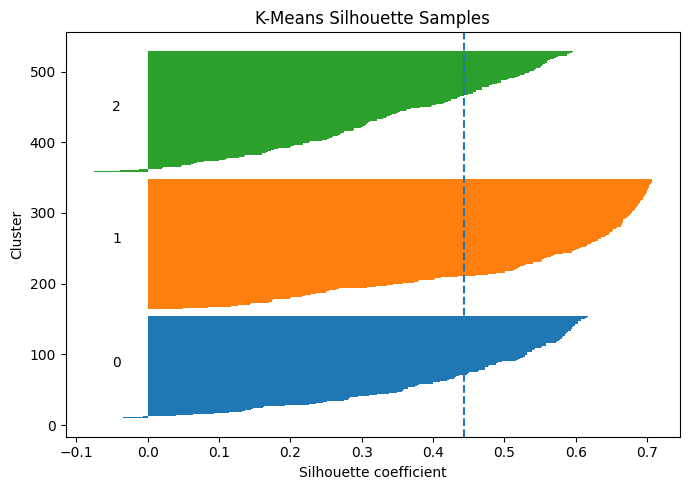

Average silhouette score: 0.444


In [11]:
silhouette_values = silhouette_samples(X_scaled, work["kmeans_cluster"])

plt.figure(figsize=(7, 5))
y_lower = 10
for cluster_id in sorted(work["kmeans_cluster"].unique()):
    cluster_values = silhouette_values[work["kmeans_cluster"] == cluster_id]
    cluster_values.sort()
    size = cluster_values.shape[0]
    y_upper = y_lower + size
    plt.barh(range(y_lower, y_upper), cluster_values, height=1.0)
    plt.text(-0.05, y_lower + 0.5 * size, str(cluster_id))
    y_lower = y_upper + 10

plt.axvline(np.mean(silhouette_values), linestyle="--")
plt.title("K-Means Silhouette Samples")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_silhouette_samples.png", dpi=160)
plt.show()

print("Average silhouette score:", round(float(np.mean(silhouette_values)), 3))


### Turning Cluster Averages into Careful Product Hints

The table above converts cluster averages into descriptive hints.

This is not a new supervised label. It is only an interpretation layer based on the average properties of each mathematical cluster.

A responsible product should phrase this carefully:

```text
This record is similar to records from this growth-profile group.
```

It should not say:

```text
This cluster proves that the dog is healthy or unhealthy.
```


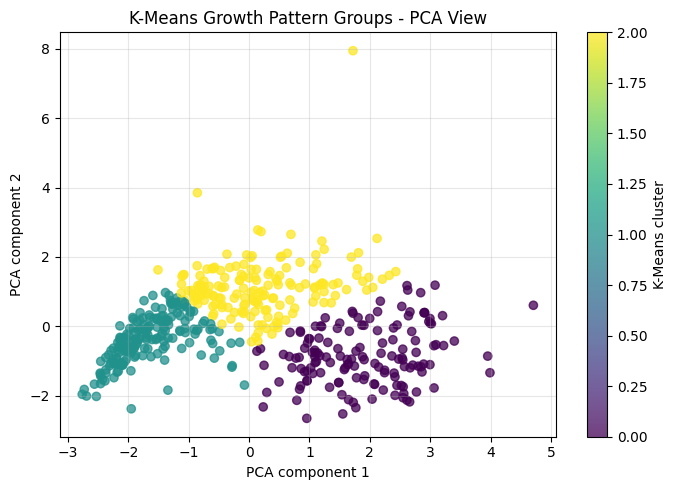

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=work["kmeans_cluster"], alpha=0.75)
plt.title("K-Means Growth Pattern Groups - PCA View")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label="K-Means cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_growth_pattern_groups_pca.png", dpi=160)
plt.show()


## 7. Hierarchical Clustering

Hierarchical clustering builds a hierarchy of groups.

In this notebook, I use agglomerative clustering:

```text
start with many small groups -> merge closest groups step by step
```

Motivation:

- useful when I want to understand nested structure;
- does not require centroids like K-Means;
- can be interpreted as a tree-like grouping process.

The downside is that it can be slower on large datasets.


In [13]:
hierarchical_scores = []

for k in range(2, 7):
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hc.fit_predict(X_scaled)
    hierarchical_scores.append(
        {
            "k": k,
            "silhouette": silhouette_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        }
    )

hierarchical_scores_df = pd.DataFrame(hierarchical_scores)
hierarchical_scores_df


,k,silhouette,davies_bouldin
0,2,0.422364,0.926329
1,3,0.423997,0.879399
2,4,0.351652,0.912046
3,5,0.365602,0.942910
4,6,0.371065,0.889549


In [14]:
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
work["hierarchical_cluster"] = hc.fit_predict(X_scaled)

hierarchical_summary = work.groupby("hierarchical_cluster")[features].mean().round(2)
hierarchical_summary["records"] = work["hierarchical_cluster"].value_counts().sort_index().values
hierarchical_summary


,visit_age_months,weight_kg,average_adult_breed_weight_kg,weight_to_adult_ratio,age_weight_ratio,adult_weight_group,records
hierarchical_cluster,,,,,,,
0,4.05,11.95,35.91,0.33,2.36,2.0,244
1,10.37,32.06,35.91,0.89,3.07,2.0,159
2,23.64,30.84,35.91,0.86,1.29,2.0,97


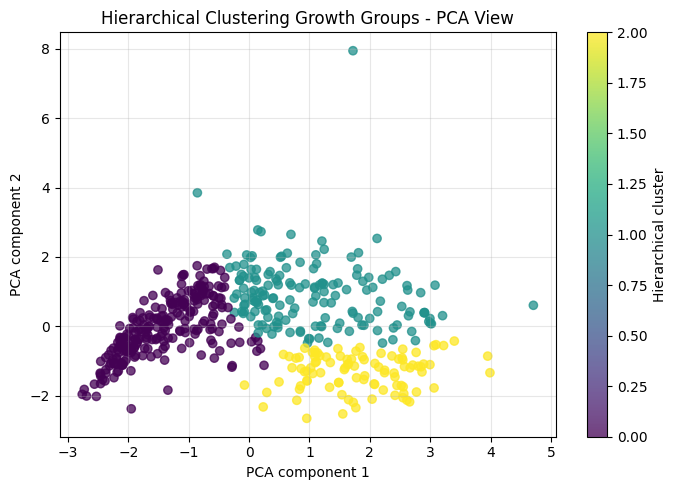

In [15]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=work["hierarchical_cluster"], alpha=0.75)
plt.title("Hierarchical Clustering Growth Groups - PCA View")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label="Hierarchical cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hierarchical_growth_groups_pca.png", dpi=160)
plt.show()


### Hierarchical Dendrogram

The lecture also shows a dendrogram. A dendrogram is useful because it visualizes how records are merged step by step based on distance.

For readability, the project uses a small sample of records. The purpose is not to label every dog, but to show the hierarchy of mathematical similarity.


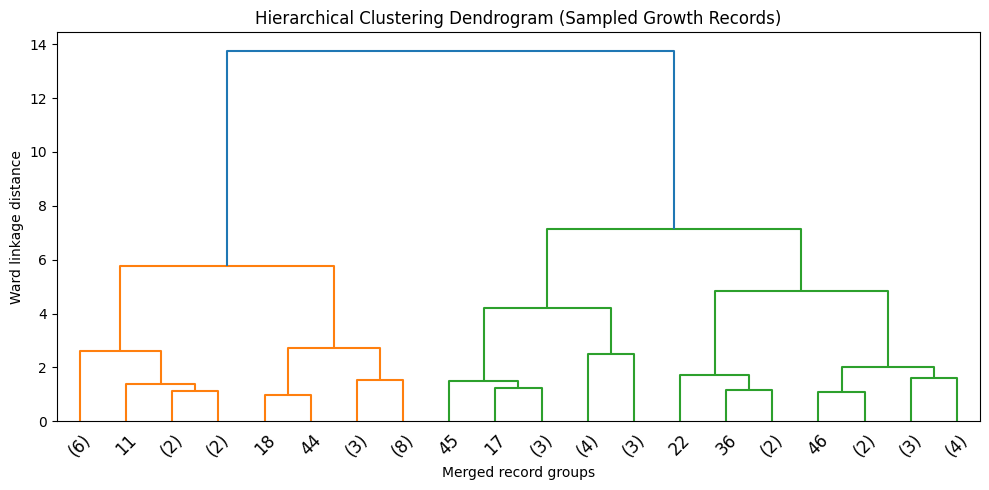

In [16]:
rng = np.random.default_rng(RANDOM_STATE)
dendrogram_size = min(50, len(X_scaled))
dendrogram_indices = rng.choice(len(X_scaled), size=dendrogram_size, replace=False)

linkage_matrix = linkage(X_scaled[dendrogram_indices], method="ward", metric="euclidean")

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20, leaf_rotation=45)
plt.title("Hierarchical Clustering Dendrogram (Sampled Growth Records)")
plt.xlabel("Merged record groups")
plt.ylabel("Ward linkage distance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "hierarchical_dendrogram_sample.png", dpi=160)
plt.show()


## 7.1 K-Means vs Hierarchical Clustering

The two methods can be compared with metrics, but the interpretation should remain careful.

- Silhouette score: higher is usually better.
- Davies-Bouldin score: lower is usually better.

These metrics help compare mathematical separation, but they do not prove that a cluster has medical meaning.


In [17]:
comparison = pd.DataFrame(
    [
        {
            "method": "K-Means",
            "k": 3,
            "silhouette": silhouette_score(X_scaled, work["kmeans_cluster"]),
            "davies_bouldin": davies_bouldin_score(X_scaled, work["kmeans_cluster"]),
        },
        {
            "method": "Hierarchical Clustering",
            "k": 3,
            "silhouette": silhouette_score(X_scaled, work["hierarchical_cluster"]),
            "davies_bouldin": davies_bouldin_score(X_scaled, work["hierarchical_cluster"]),
        },
    ]
).round(4)

comparison


,method,k,silhouette,davies_bouldin
0,K-Means,3,0.4437,0.8090
1,Hierarchical Clustering,3,0.4240,0.8794


### Pros and Cons

| Method | Pros | Cons | Project interpretation |
|---|---|---|---|
| K-Means | fast, simple, easy cluster centers | must choose k, assumes rounded clusters, sensitive to scaling/outliers | good first grouping of growth profiles |
| Hierarchical Clustering | shows nested grouping idea, no centroid assumption | can be slower, still needs a cut level / number of groups | useful for exploring similarity structure |


## 8. DBSCAN

DBSCAN is density-based. It groups points that are close and dense, and it can mark sparse points as noise.

Important parameters:

- `eps`: neighborhood radius;
- `min_samples`: minimum number of nearby points required to form dense region.

This is useful because unusual records may appear as noise instead of being forced into a cluster.


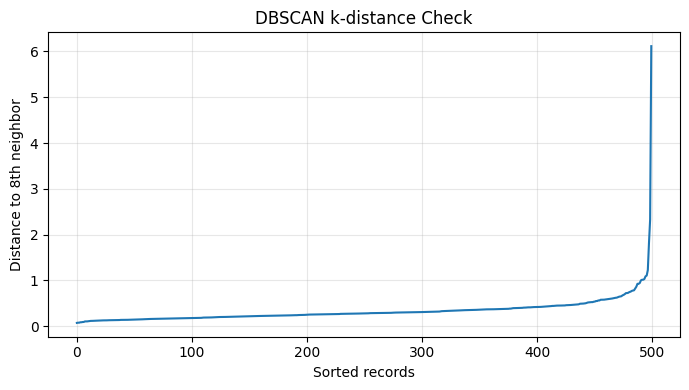

In [18]:
min_samples = 8
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distances)
plt.title("DBSCAN k-distance Check")
plt.xlabel("Sorted records")
plt.ylabel(f"Distance to {min_samples}th neighbor")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dbscan_k_distance_check.png", dpi=160)
plt.show()


In [19]:
dbscan = DBSCAN(eps=0.35, min_samples=min_samples)
work["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

dbscan_cluster_count = len(set(work["dbscan_cluster"]) - {-1})
dbscan_noise_rate = (work["dbscan_cluster"] == -1).mean()

print("DBSCAN clusters excluding noise:", dbscan_cluster_count)
print("DBSCAN noise rate:", round(dbscan_noise_rate, 3))
work["dbscan_cluster"].value_counts().sort_index()


DBSCAN clusters excluding noise: 5
DBSCAN noise rate: 0.196


dbscan_cluster
-1     98
 0    319
 1     48
 2     10
 3     16
 4      9
Name: count, dtype: int64

### DBSCAN Noise as Review Candidates

DBSCAN can mark some records as `-1`, meaning noise.

In the product idea, these records can become **review candidates**, not automatic warnings. The system could say:

```text
This record does not fit one of the dense growth-profile groups in this dataset.
Please review the measurements, context and growth history.
```


In [20]:
review_columns = [
    "visit_age_months",
    "weight_kg",
    "average_adult_breed_weight_kg",
    "weight_to_adult_ratio",
    "age_weight_ratio",
    "dbscan_cluster",
]

dbscan_review_examples = work.loc[work["dbscan_cluster"] == -1, review_columns].copy()
dbscan_review_examples["review_reason"] = "outside dense DBSCAN neighborhoods"

if dbscan_review_examples.empty:
    print("No DBSCAN noise records found with the current eps/min_samples settings.")
else:
    dbscan_review_examples.head(10)


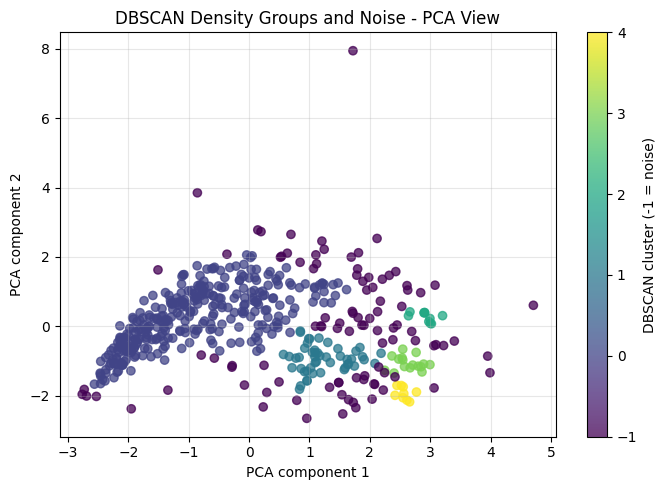

In [21]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=work["dbscan_cluster"], alpha=0.75)
plt.title("DBSCAN Density Groups and Noise - PCA View")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label="DBSCAN cluster (-1 = noise)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dbscan_density_groups_pca.png", dpi=160)
plt.show()


## 9. Clustering and Classification: How They Connect

The lecture explains that clustering and classification can be compared on the same data. The difference is important:

```text
Classification uses known labels y.
Clustering ignores labels and tries to discover groups from X alone.
```

Cluster IDs are arbitrary, so raw accuracy is not the right comparison. A better educational comparison is the **Adjusted Rand Index (ARI)**, which measures how similar two groupings are while ignoring the numeric names of the clusters.


In [22]:
growth_band_codes = work["growth_ratio_band"].cat.codes

clustering_classification_comparison = pd.DataFrame(
    [
        {
            "comparison": "K-Means clusters vs educational growth-ratio bands",
            "ARI": adjusted_rand_score(growth_band_codes, work["kmeans_cluster"]),
            "meaning": "How similar the unsupervised groups are to the derived ratio bands",
        },
        {
            "comparison": "Hierarchical clusters vs educational growth-ratio bands",
            "ARI": adjusted_rand_score(growth_band_codes, work["hierarchical_cluster"]),
            "meaning": "How similar hierarchical groups are to the derived ratio bands",
        },
    ]
)

clustering_classification_comparison.round(3)


,comparison,ARI,meaning
0,K-Means clusters vs educational growth-ratio b...,0.493,How similar the unsupervised groups are to the...
1,Hierarchical clusters vs educational growth-ra...,0.365,How similar hierarchical groups are to the der...


### Responsible Interpretation

A low or medium ARI does not mean the clustering is useless. It may mean that the clustering discovers structure different from the manually created bands. That is the point of unsupervised learning: it may reveal patterns we did not explicitly label.

In a practical growth-monitoring assistant, this can support a message such as:

```text
This record belongs to a mathematical similarity group. Review it together with age, weight history, breed-size context and professional judgement.
```


## 10. Final Interpretation

The clustering stage adds a new type of machine-learning insight to the project:

```text
not prediction -> discovery of possible natural groups
```

Practical interpretation for Cane Corso Growth Intelligence:

- K-Means can provide simple growth-pattern groups;
- Hierarchical Clustering can show similarity structure;
- DBSCAN can flag records that do not fit dense groups;
- cluster summaries can be translated into careful educational profile hints;
- all clusters must remain exploratory and require human interpretation.

The important mathematical idea is that the real-world problem becomes a geometric problem:

```text
growth record -> feature vector -> scaled coordinate space -> distance/density structure -> careful interpretation
```

This completes the core requirements from the Unsupervised Learning and Clustering lecture while keeping the notebook connected to an applicable project idea.

Final safety boundary:

```text
The clustering output is useful for learning, monitoring and review prioritization.
It is not veterinary diagnosis, not a health certificate and not official breed proof.
```
